# House Prices — Modelagem e Avaliação

**Objetivo:** Treinar, comparar e avaliar três modelos de Machine Learning para prever o preço de venda de imóveis.  
**Modelos utilizados:**
1. Regressão Linear 
2. Random Forest Regressor 
3. Gradient Boosting Regressor 

**Métrica principal:** RMSE no espaço original de preços (após reverter log1p)  
**Métrica secundária:** R² (coeficiente de determinação)

## 0. Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

RANDOM_STATE = 42
print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


## 1. Carregamento dos dados processados

In [2]:
X_train = pd.read_csv('../data/X_train.csv')
X_val   = pd.read_csv('../data/X_val.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_val   = pd.read_csv('../data/y_val.csv').squeeze()
y_original = pd.read_csv('../data/y_original.csv').squeeze()

# Alvo de validação no espaço original (para métricas em USD)
# y_val está em log — precisamos do original correspondente
y_val_original = np.expm1(y_val)

print(f'X_train: {X_train.shape}')
print(f'X_val:   {X_val.shape}')
print(f'Features: {X_train.shape[1]}')

X_train: (1166, 56)
X_val:   (292, 56)
Features: 56


## 2. Funções auxiliares de avaliação

In [3]:
def avaliar_modelo(nome, modelo, X_tr, y_tr, X_v, y_v_log, y_v_original):
    """
    Treina o modelo, calcula métricas no espaço log e no espaço original (USD).
    Retorna dicionário com todas as métricas.
    """
    # Treino
    modelo.fit(X_tr, y_tr)

    # Predições no espaço log
    y_pred_log_train = modelo.predict(X_tr)
    y_pred_log_val   = modelo.predict(X_v)

    # Reverter para espaço original (USD)
    y_pred_train_usd = np.expm1(y_pred_log_train)
    y_pred_val_usd   = np.expm1(y_pred_log_val)
    y_train_usd      = np.expm1(y_tr)

    # Métricas
    rmse_train = np.sqrt(mean_squared_error(y_train_usd, y_pred_train_usd))
    rmse_val   = np.sqrt(mean_squared_error(y_v_original, y_pred_val_usd))
    mae_val    = mean_absolute_error(y_v_original, y_pred_val_usd)
    r2_train   = r2_score(y_tr, y_pred_log_train)
    r2_val     = r2_score(y_v_log, y_pred_log_val)

    # Cross-validation no treino (5-fold)
    cv_scores = cross_val_score(modelo, X_tr, y_tr,
                                cv=5, scoring='neg_root_mean_squared_error')
    cv_rmse_log = -cv_scores.mean()

    resultado = {
        'modelo':       nome,
        'rmse_train':   rmse_train,
        'rmse_val':     rmse_val,
        'mae_val':      mae_val,
        'r2_train':     r2_train,
        'r2_val':       r2_val,
        'cv_rmse_log':  cv_rmse_log,
        'y_pred_val':   y_pred_val_usd,
        'fitted':       modelo
    }

    print(f'\n{"="*50}')
    print(f'  {nome}')
    print(f'{"="*50}')
    print(f'  RMSE Treino:      ${rmse_train:>12,.0f}')
    print(f'  RMSE Validação:   ${rmse_val:>12,.0f}')
    print(f'  MAE  Validação:   ${mae_val:>12,.0f}')
    print(f'  R²   Treino:       {r2_train:>11.4f}')
    print(f'  R²   Validação:    {r2_val:>11.4f}')
    print(f'  CV RMSE (5-fold):  {cv_rmse_log:>11.4f} (espaço log)')

    return resultado

## 3. Modelo 1 — Regressão Linear (baseline)

**Justificativa:** Modelo mais simples possível. Serve como baseline — qualquer modelo mais complexo deve superá-lo.
Assume relação linear entre as features e o alvo. Sensível a multicolinearidade.

Usamos também a variante Ridge (regularização L2) para comparar o efeito da regularização.

In [4]:
lr = LinearRegression()
res_lr = avaliar_modelo(
    'Regressão Linear',
    lr, X_train, y_train, X_val, y_val, y_val_original
)


  Regressão Linear
  RMSE Treino:      $      21,551
  RMSE Validação:   $      21,307
  MAE  Validação:   $      15,490
  R²   Treino:            0.9117
  R²   Validação:         0.8996
  CV RMSE (5-fold):       0.1273 (espaço log)


In [5]:
# Ridge — mesma lógica mas com penalização de coeficientes grandes
# alpha=10 é um valor padrão razoável para este dataset
ridge = Ridge(alpha=10, random_state=RANDOM_STATE)
res_ridge = avaliar_modelo(
    'Ridge (L2)',
    ridge, X_train, y_train, X_val, y_val, y_val_original
)


  Ridge (L2)
  RMSE Treino:      $      21,559
  RMSE Validação:   $      21,333
  MAE  Validação:   $      15,523
  R²   Treino:            0.9117
  R²   Validação:         0.8994
  CV RMSE (5-fold):       0.1268 (espaço log)


## 4. Modelo 2 — Random Forest Regressor

**Justificativa:** Ensemble de árvores de decisão. Robusto a outliers e não exige normalização.
Captura relações não-lineares (como o efeito exponencial de OverallQual identificado na H2).
Hiperparâmetros conservadores para evitar overfitting com poucos dados.

In [6]:
rf = RandomForestRegressor(
    n_estimators=300,    # 300 árvores — equilíbrio entre performance e tempo
    max_depth=15,        # limita profundidade para evitar overfitting
    min_samples_leaf=3,  # cada folha precisa de ao menos 3 amostras
    n_jobs=-1,           # usa todos os núcleos disponíveis
    random_state=RANDOM_STATE
)
res_rf = avaliar_modelo(
    'Random Forest',
    rf, X_train, y_train, X_val, y_val, y_val_original
)


  Random Forest
  RMSE Treino:      $      14,246
  RMSE Validação:   $      24,613
  MAE  Validação:   $      16,947
  R²   Treino:            0.9672
  R²   Validação:         0.8615
  CV RMSE (5-fold):       0.1405 (espaço log)


## 5. Modelo 3 — Gradient Boosting Regressor

**Justificativa:** Constrói árvores sequencialmente, cada uma corrigindo os erros da anterior.
Geralmente o modelo de maior performance em datasets tabulares de tamanho médio.
learning_rate baixo + mais estimadores tende a generalizar melhor.

In [7]:
gb = GradientBoostingRegressor(
    n_estimators=500,    # mais estimadores compensam o learning_rate baixo
    learning_rate=0.05,  # passos pequenos — mais estável
    max_depth=4,         # árvores rasas para evitar overfitting
    min_samples_leaf=3,
    subsample=0.8,       # usa 80% dos dados por árvore (estocástico)
    random_state=RANDOM_STATE
)
res_gb = avaliar_modelo(
    'Gradient Boosting',
    gb, X_train, y_train, X_val, y_val, y_val_original
)


  Gradient Boosting
  RMSE Treino:      $       5,867
  RMSE Validação:   $      20,715
  MAE  Validação:   $      14,918
  R²   Treino:            0.9931
  R²   Validação:         0.8961
  CV RMSE (5-fold):       0.1282 (espaço log)


## 6. Comparação entre modelos

In [8]:
# Tabela comparativa
resultados = [res_lr, res_ridge, res_rf, res_gb]
tabela = pd.DataFrame([{
    'Modelo':          r['modelo'],
    'RMSE Treino':     f"${r['rmse_train']:,.0f}",
    'RMSE Validação':  f"${r['rmse_val']:,.0f}",
    'MAE Validação':   f"${r['mae_val']:,.0f}",
    'R² Treino':       f"{r['r2_train']:.4f}",
    'R² Validação':    f"{r['r2_val']:.4f}",
} for r in resultados])

print('\nTABELA COMPARATIVA DE MODELOS')
print(tabela.to_string(index=False))


TABELA COMPARATIVA DE MODELOS
           Modelo RMSE Treino RMSE Validação MAE Validação R² Treino R² Validação
 Regressão Linear     $21,551        $21,307       $15,490    0.9117       0.8996
       Ridge (L2)     $21,559        $21,333       $15,523    0.9117       0.8994
    Random Forest     $14,246        $24,613       $16,947    0.9672       0.8615
Gradient Boosting      $5,867        $20,715       $14,918    0.9931       0.8961


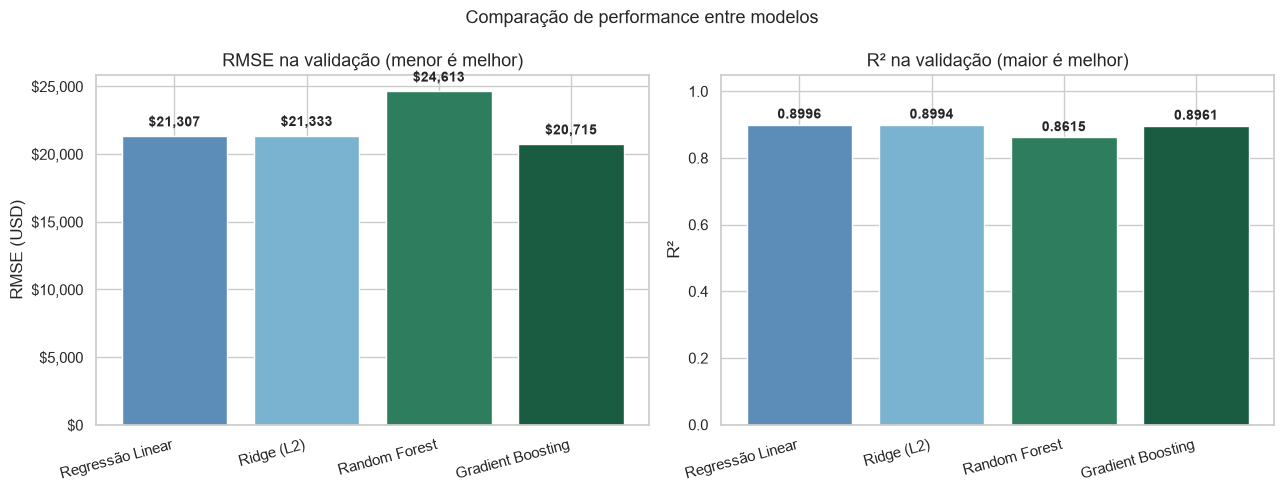

In [9]:
# Gráfico de barras — RMSE validação
nomes   = [r['modelo'] for r in resultados]
rmses   = [r['rmse_val'] for r in resultados]
r2s     = [r['r2_val'] for r in resultados]
cores   = ['#5b8db8', '#7ab3d0', '#2e7d5e', '#1a5c42']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# RMSE
bars = axes[0].bar(nomes, rmses, color=cores, edgecolor='white')
axes[0].set_title('RMSE na validação (menor é melhor)')
axes[0].set_ylabel('RMSE (USD)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(bars, rmses):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'${val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.setp(axes[0].get_xticklabels(), rotation=15, ha='right')

# R²
bars2 = axes[1].bar(nomes, r2s, color=cores, edgecolor='white')
axes[1].set_title('R² na validação (maior é melhor)')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1.05)
for bar, val in zip(bars2, r2s):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.setp(axes[1].get_xticklabels(), rotation=15, ha='right')

plt.suptitle('Comparação de performance entre modelos', fontsize=13)
plt.tight_layout()
plt.savefig('../report/fig14_comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Análise de resíduos do melhor modelo

Melhor modelo: Gradient Boosting (RMSE val = $20,715)


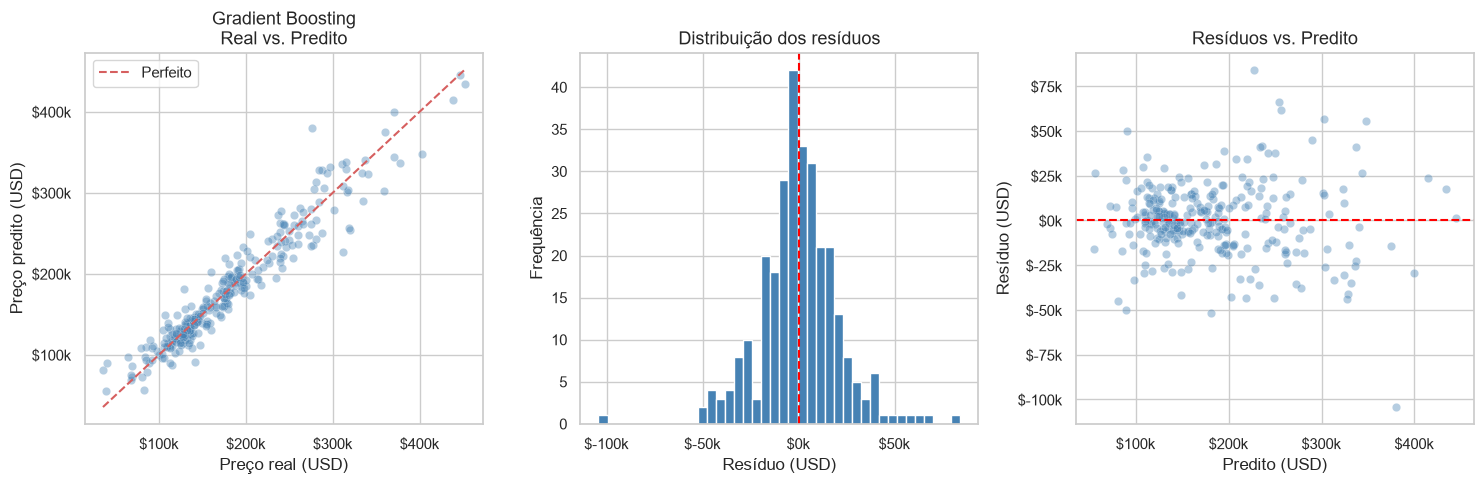

Resíduo médio:    $214
Resíduo mediano:  $-378
Erro médio %:     9.3%


In [10]:
# Identificar melhor modelo pelo menor RMSE de validação
melhor = min(resultados, key=lambda r: r['rmse_val'])
print(f'Melhor modelo: {melhor["modelo"]} (RMSE val = ${melhor["rmse_val"]:,.0f})')

y_pred_melhor = melhor['y_pred_val']
residuos = y_val_original.values - y_pred_melhor
residuos_pct = residuos / y_val_original.values * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Real vs Predito
axes[0].scatter(y_val_original, y_pred_melhor, alpha=0.4, color='steelblue', edgecolors='white', linewidths=0.3)
lim_min = min(y_val_original.min(), y_pred_melhor.min())
lim_max = max(y_val_original.max(), y_pred_melhor.max())
axes[0].plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1.5, label='Perfeito')
axes[0].set_title(f'{melhor["modelo"]}\nReal vs. Predito')
axes[0].set_xlabel('Preço real (USD)')
axes[0].set_ylabel('Preço predito (USD)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].legend()

# Distribuição dos resíduos
axes[1].hist(residuos, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_title('Distribuição dos resíduos')
axes[1].set_xlabel('Resíduo (USD)')
axes[1].set_ylabel('Frequência')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# Resíduos vs Predito
axes[2].scatter(y_pred_melhor, residuos, alpha=0.4, color='steelblue', edgecolors='white', linewidths=0.3)
axes[2].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[2].set_title('Resíduos vs. Predito')
axes[2].set_xlabel('Predito (USD)')
axes[2].set_ylabel('Resíduo (USD)')
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('../report/fig15_residuos.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Resíduo médio:    ${residuos.mean():,.0f}')
print(f'Resíduo mediano:  ${np.median(residuos):,.0f}')
print(f'Erro médio %:     {np.abs(residuos_pct).mean():.1f}%')

## 8. Importância das features (Random Forest e Gradient Boosting)

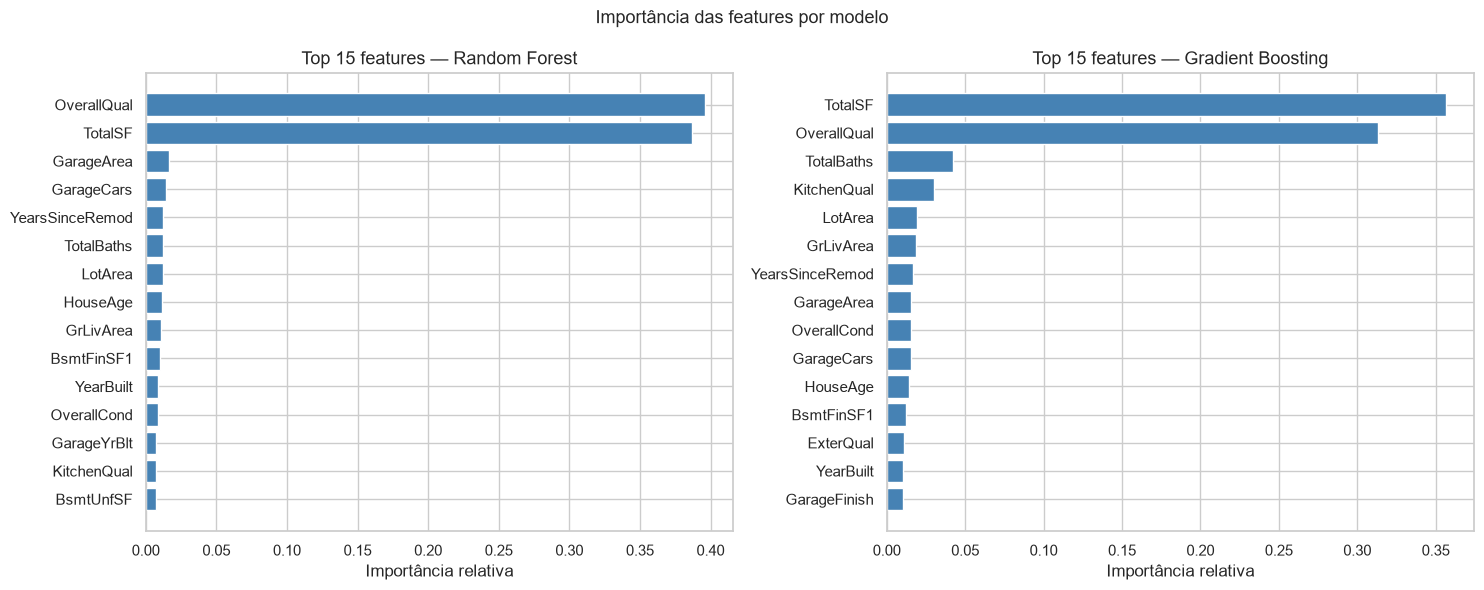

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, res, titulo in zip(axes, [res_rf, res_gb], ['Random Forest', 'Gradient Boosting']):
    importancias = pd.Series(
        res['fitted'].feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False).head(15)

    ax.barh(importancias.index[::-1], importancias.values[::-1], color='steelblue', edgecolor='white')
    ax.set_title(f'Top 15 features — {titulo}')
    ax.set_xlabel('Importância relativa')

plt.suptitle('Importância das features por modelo', fontsize=13)
plt.tight_layout()
plt.savefig('../report/fig16_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Exportação do melhor modelo

In [12]:
# Salvar o melhor modelo para uso no dashboard
joblib.dump(melhor['fitted'], '../data/melhor_modelo.pkl')
print(f'Modelo salvo: {melhor["modelo"]} → ../data/melhor_modelo.pkl')

# Salvar todos os modelos para referência
for res in resultados:
    nome_arquivo = res['modelo'].lower().replace(' ', '_').replace('(', '').replace(')', '')
    joblib.dump(res['fitted'], f'../data/modelo_{nome_arquivo}.pkl')

# Salvar tabela de resultados
tabela_export = pd.DataFrame([{
    'modelo':       r['modelo'],
    'rmse_train':   round(r['rmse_train'], 2),
    'rmse_val':     round(r['rmse_val'], 2),
    'mae_val':      round(r['mae_val'], 2),
    'r2_train':     round(r['r2_train'], 4),
    'r2_val':       round(r['r2_val'], 4),
    'cv_rmse_log':  round(r['cv_rmse_log'], 4),
} for r in resultados])
tabela_export.to_csv('../data/resultados_modelos.csv', index=False)

print('\nArquivos exportados:')
print('  ../data/melhor_modelo.pkl')
print('  ../data/resultados_modelos.csv')
print('\nNotebook 03_modeling concluído.')
print(f'\nMelhor modelo: {melhor["modelo"]}')
print(f'RMSE validação: ${melhor["rmse_val"]:,.0f}')
print(f'R² validação:   {melhor["r2_val"]:.4f}')

Modelo salvo: Gradient Boosting → ../data/melhor_modelo.pkl

Arquivos exportados:
  ../data/melhor_modelo.pkl
  ../data/resultados_modelos.csv

Notebook 03_modeling concluído.

Melhor modelo: Gradient Boosting
RMSE validação: $20,715
R² validação:   0.8961
